# Quick Commerce Data Analysis
**Dataset:** Quick Commerce Dataset from Kaggle  
**Goal:** Extract, transform, load, and analyze 947,752 quick commerce orders  
**Author:** Joemar De Vera

---
## 1. Extract — Load Data from Kaggle
We load the dataset using the Kaggle API and take a first look at the raw data.

In [1]:
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt
import kagglehub
from kagglehub import KaggleDatasetAdapter

# Load dataset from Kaggle
df = kagglehub.dataset_load(
    KaggleDatasetAdapter.PANDAS,
    "rohitgrewal/quick-commerce-dataset",
    "quick_commerce_data_modified_cleaned.csv",
)

print(f"Rows: {len(df):,}")
print(f"Columns: {list(df.columns)}")
df.head()

c:\Users\User\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Rows: 947,752
Columns: ['Order_ID', 'Company', 'City', 'Customer_Age', 'Order_Value', 'Delivery_Time_Min', 'Distance_Km', 'Items_Count', 'Product_Category', 'Payment_Method', 'Customer_Rating', 'Discount_Applied', 'Delivery_Partner_Rating']


,Order_ID,Company,City,Customer_Age,Order_Value,Delivery_Time_Min,Distance_Km,Items_Count,Product_Category,Payment_Method,Customer_Rating,Discount_Applied,Delivery_Partner_Rating
0,1000001,Swiggy Instamart,Noida,46,702,19,12.0,12,Dairy,Wallet,2,1,3
1,1000002,Flipkart Minutes,Amritsar,56,1007,20,12.7,10,Snacks,Cash on Delivery,2,0,3
2,1000003,Flipkart Minutes,Mumbai,18,1212,17,4.8,19,Personal Care,Cash on Delivery,3,0,4
3,1000004,Swiggy Instamart,Delhi,23,1179,6,6.4,2,Dairy,Credit Card,5,1,5
4,1000005,Dunzo,Mumbai,44,586,12,2.4,13,Household,Wallet,4,0,5


### 1.1 Basic Data Exploration
Check data types, null values, and basic statistics.

In [2]:
# Data types and null values
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 947752 entries, 0 to 947751
Data columns (total 13 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   Order_ID                 947752 non-null  int64  
 1   Company                  947752 non-null  object 
 2   City                     947752 non-null  object 
 3   Customer_Age             947752 non-null  int64  
 4   Order_Value              947752 non-null  int64  
 5   Delivery_Time_Min        947752 non-null  int64  
 6   Distance_Km              947752 non-null  float64
 7   Items_Count              947752 non-null  int64  
 8   Product_Category         947752 non-null  object 
 9   Payment_Method           947752 non-null  object 
 10  Customer_Rating          947752 non-null  int64  
 11  Discount_Applied         947752 non-null  int64  
 12  Delivery_Partner_Rating  947752 non-null  int64  
dtypes: float64(1), int64(8), object(4)
memory usage: 94.0+ MB


In [3]:
# Statistical summary
df.describe()

,Order_ID,Customer_Age,Order_Value,Delivery_Time_Min,Distance_Km,Items_Count,Customer_Rating,Discount_Applied,Delivery_Partner_Rating
count,9.477520e+05,947752.000000,947752.000000,947752.000000,947752.000000,947752.000000,947752.000000,947752.000000,947752.000000
mean,1.500028e+06,38.471165,570.912008,16.506620,7.750048,10.313292,3.042655,0.400786,3.800295
std,2.887273e+05,12.118982,374.175332,6.340851,4.187153,5.630770,1.202499,0.490058,0.718762
min,1.000001e+06,18.000000,50.000000,5.000000,0.500000,1.000000,1.000000,0.000000,2.000000
25%,1.249939e+06,28.000000,288.000000,12.000000,4.100000,5.000000,2.000000,0.000000,3.000000
50%,1.500026e+06,38.000000,532.000000,16.000000,7.800000,10.000000,3.000000,0.000000,4.000000
75%,1.750145e+06,49.000000,797.000000,20.000000,11.400000,15.000000,4.000000,1.000000,4.000000
max,2.000000e+06,59.000000,2492.000000,40.000000,15.000000,19.000000,5.000000,1.000000,5.000000


---
## 2. Transform — Build Star Schema
We split the flat CSV into 4 tables following a **star schema** design:
- `fact_orders` — the main table with all order events
- `dim_customers` — customer dimension
- `dim_delivery_partners` — delivery partner dimension
- `dim_promotions` — promotions/discount dimension

In [4]:
# --- dim_customers ---
dim_customers = df[['Order_ID', 'Customer_Age']].copy()
dim_customers['customer_id'] = range(1, len(dim_customers) + 1)
dim_customers = dim_customers.rename(columns={'Customer_Age': 'customer_age'})
dim_customers = dim_customers[['customer_id', 'customer_age']]

# --- dim_delivery_partners ---
dim_partners = df[['Delivery_Partner_Rating']].drop_duplicates().copy()
dim_partners['partner_id'] = range(1, len(dim_partners) + 1)
dim_partners = dim_partners.rename(columns={'Delivery_Partner_Rating': 'delivery_partner_rating'})
dim_partners = dim_partners[['partner_id', 'delivery_partner_rating']]

# --- dim_promotions ---
dim_promotions = df[['Discount_Applied']].drop_duplicates().copy()
dim_promotions['promo_id'] = range(1, len(dim_promotions) + 1)
dim_promotions = dim_promotions.rename(columns={'Discount_Applied': 'discount_applied'})
dim_promotions = dim_promotions[['promo_id', 'discount_applied']]

# --- fact_orders (includes all columns) ---
fact_orders = df.rename(columns={
    'Order_ID':                'order_id',
    'Order_Value':             'order_value',
    'Delivery_Time_Min':       'delivery_time_min',
    'Distance_Km':             'distance_km',
    'Items_Count':             'items_count',
    'Customer_Rating':         'customer_rating',
    'Discount_Applied':        'discount_applied',
    'Delivery_Partner_Rating': 'delivery_partner_rating',
    'Customer_Age':            'customer_age',
})
fact_orders = fact_orders[[
    'order_id', 'order_value', 'delivery_time_min',
    'distance_km', 'items_count', 'customer_rating',
    'discount_applied', 'delivery_partner_rating', 'customer_age',
]]

print("=== dim_customers ===")
print(dim_customers.head())
print("\n=== dim_delivery_partners ===")
print(dim_partners.head())
print("\n=== dim_promotions ===")
print(dim_promotions.head())
print("\n=== fact_orders ===")
print(fact_orders.head())

=== dim_customers ===
   customer_id  customer_age
0            1            46
1            2            56
2            3            18
3            4            23
4            5            44

=== dim_delivery_partners ===
    partner_id  delivery_partner_rating
0            1                        3
2            2                        4
3            3                        5
20           4                        2

=== dim_promotions ===
   promo_id  discount_applied
0         1                 1
1         2                 0

=== fact_orders ===
   order_id  order_value  delivery_time_min  distance_km  items_count  \
0   1000001          702                 19         12.0           12   
1   1000002         1007                 20         12.7           10   
2   1000003         1212                 17          4.8           19   
3   1000004         1179                  6          6.4            2   
4   1000005          586                 12          2.4           13   


---
## 3. Load — Save to SQLite Database
We load all 4 tables into a local SQLite database called `quick_commerce.db`.

In [5]:
# Connect to SQLite database (creates file if it doesn't exist)
conn = sqlite3.connect("quick_commerce.db")

# Load all tables
dim_customers.to_sql("dim_customers", conn, if_exists="replace", index=False)
dim_partners.to_sql("dim_delivery_partners", conn, if_exists="replace", index=False)
dim_promotions.to_sql("dim_promotions", conn, if_exists="replace", index=False)
fact_orders.to_sql("fact_orders", conn, if_exists="replace", index=False)

conn.commit()

# Verify row counts
cursor = conn.cursor()
print("=== Row Counts ===")
for table in ["dim_customers", "dim_delivery_partners", "dim_promotions", "fact_orders"]:
    count = cursor.execute(f"SELECT COUNT(*) FROM {table}").fetchone()[0]
    print(f"{table}: {count:,} rows")

print("\nDatabase saved as quick_commerce.db")

=== Row Counts ===
dim_customers: 947,752 rows
dim_delivery_partners: 4 rows
dim_promotions: 2 rows
fact_orders: 947,752 rows

Database saved as quick_commerce.db


---
## 4. Analyze — SQL Business Questions
Now we query the database to answer real business questions.

### Q1: What is the average delivery time?

In [6]:
q1 = pd.read_sql_query("""
    SELECT 
        ROUND(AVG(delivery_time_min), 2) AS avg_delivery_time,
        ROUND(MIN(delivery_time_min), 2) AS min_delivery_time,
        ROUND(MAX(delivery_time_min), 2) AS max_delivery_time
    FROM fact_orders
""", conn)
print("Average delivery time is 16.51 mins, ranging from 5 to 40 mins")
q1

Average delivery time is 16.51 mins, ranging from 5 to 40 mins


,avg_delivery_time,min_delivery_time,max_delivery_time
0,16.51,5.0,40.0


### Q2: Do discounts lead to higher order values?

In [7]:
q2 = pd.read_sql_query("""
    SELECT 
        CASE WHEN discount_applied = 1 THEN 'Yes' ELSE 'No' END AS discount,
        ROUND(AVG(order_value), 2)     AS avg_order_value,
        ROUND(AVG(customer_rating), 2) AS avg_customer_rating,
        COUNT(*)                        AS total_orders
    FROM fact_orders
    GROUP BY discount_applied
""", conn)
print("Orders with discounts average higher order values (712 vs 476)")
q2

Orders with discounts average higher order values (712 vs 476)


,discount,avg_order_value,avg_customer_rating,total_orders
0,No,476.42,3.04,567906
1,Yes,712.19,3.04,379846


### Q3: Does distance affect delivery time?

In [8]:
q3 = pd.read_sql_query("""
    SELECT 
        CASE 
            WHEN distance_km <= 5  THEN '0-5 km'
            WHEN distance_km <= 10 THEN '5-10 km'
            ELSE '10+ km'
        END AS distance_range,
        ROUND(AVG(delivery_time_min), 2) AS avg_delivery_time,
        COUNT(*) AS total_orders
    FROM fact_orders
    GROUP BY distance_range
    ORDER BY avg_delivery_time
""", conn)
print("Longer distance = longer delivery time (13.67 to 19.27 mins)")
q3

Longer distance = longer delivery time (13.67 to 19.27 mins)


,distance_range,avg_delivery_time,total_orders
0,0-5 km,13.67,297747
1,5-10 km,16.36,326979
2,10+ km,19.27,323026


### Q4: What order value range is most common?

In [9]:
q4 = pd.read_sql_query("""
    SELECT 
        CASE 
            WHEN order_value <= 300  THEN 'Low (0-300)'
            WHEN order_value <= 800  THEN 'Medium (300-800)'
            WHEN order_value <= 1500 THEN 'High (800-1500)'
            ELSE 'Premium (1500+)'
        END AS order_category,
        COUNT(*) AS total_orders,
        ROUND(AVG(customer_rating), 2) AS avg_rating
    FROM fact_orders
    GROUP BY order_category
    ORDER BY total_orders DESC
""", conn)
print("Medium orders (300-800) are most common with 465,860 orders")
q4

Medium orders (300-800) are most common with 465,860 orders


,order_category,total_orders,avg_rating
0,Medium (300-800),465860,3.03
1,Low (0-300),247783,3.01
2,High (800-1500),216817,3.09
3,Premium (1500+),17292,3.17


### Q5: How do delivery partner ratings affect performance?

In [10]:
q5 = pd.read_sql_query("""
    SELECT 
        delivery_partner_rating,
        COUNT(*)                         AS total_deliveries,
        ROUND(AVG(delivery_time_min), 2) AS avg_delivery_time,
        ROUND(AVG(customer_rating), 2)   AS avg_customer_rating,
        ROUND(AVG(order_value), 2)       AS avg_order_value
    FROM fact_orders
    GROUP BY delivery_partner_rating
    ORDER BY delivery_partner_rating DESC
""", conn)
print("All delivery partners perform consistently (~16.5 mins average)")
q5

All delivery partners perform consistently (~16.5 mins average)


,delivery_partner_rating,total_deliveries,avg_delivery_time,avg_customer_rating,avg_order_value
0,5,152226,16.50,3.05,569.04
1,4,470880,16.48,3.04,571.76
2,3,307795,16.55,3.04,570.48
3,2,16851,16.48,3.04,571.91


### Q6: Which age group orders the most?

In [11]:
q6 = pd.read_sql_query("""
    SELECT 
        CASE 
            WHEN customer_age BETWEEN 18 AND 25 THEN '18-25'
            WHEN customer_age BETWEEN 26 AND 35 THEN '26-35'
            WHEN customer_age BETWEEN 36 AND 45 THEN '36-45'
            ELSE '46+'
        END AS age_group,
        COUNT(*)                         AS total_orders,
        ROUND(AVG(order_value), 2)       AS avg_order_value,
        ROUND(AVG(delivery_time_min), 2) AS avg_delivery_time,
        ROUND(AVG(customer_rating), 2)   AS avg_rating
    FROM fact_orders
    GROUP BY age_group
    ORDER BY age_group
""", conn)
print("46+ age group places the most orders (314,724)")
q6

46+ age group places the most orders (314,724)


,age_group,total_orders,avg_order_value,avg_delivery_time,avg_rating
0,18-25,180789,571.84,16.50,3.05
1,26-35,226235,569.94,16.51,3.04
2,36-45,226004,570.83,16.50,3.04
3,46+,314724,571.13,16.51,3.04


---
## 5. Visualize — Analytics Dashboard
We build a 4-chart dashboard summarizing the key insights.

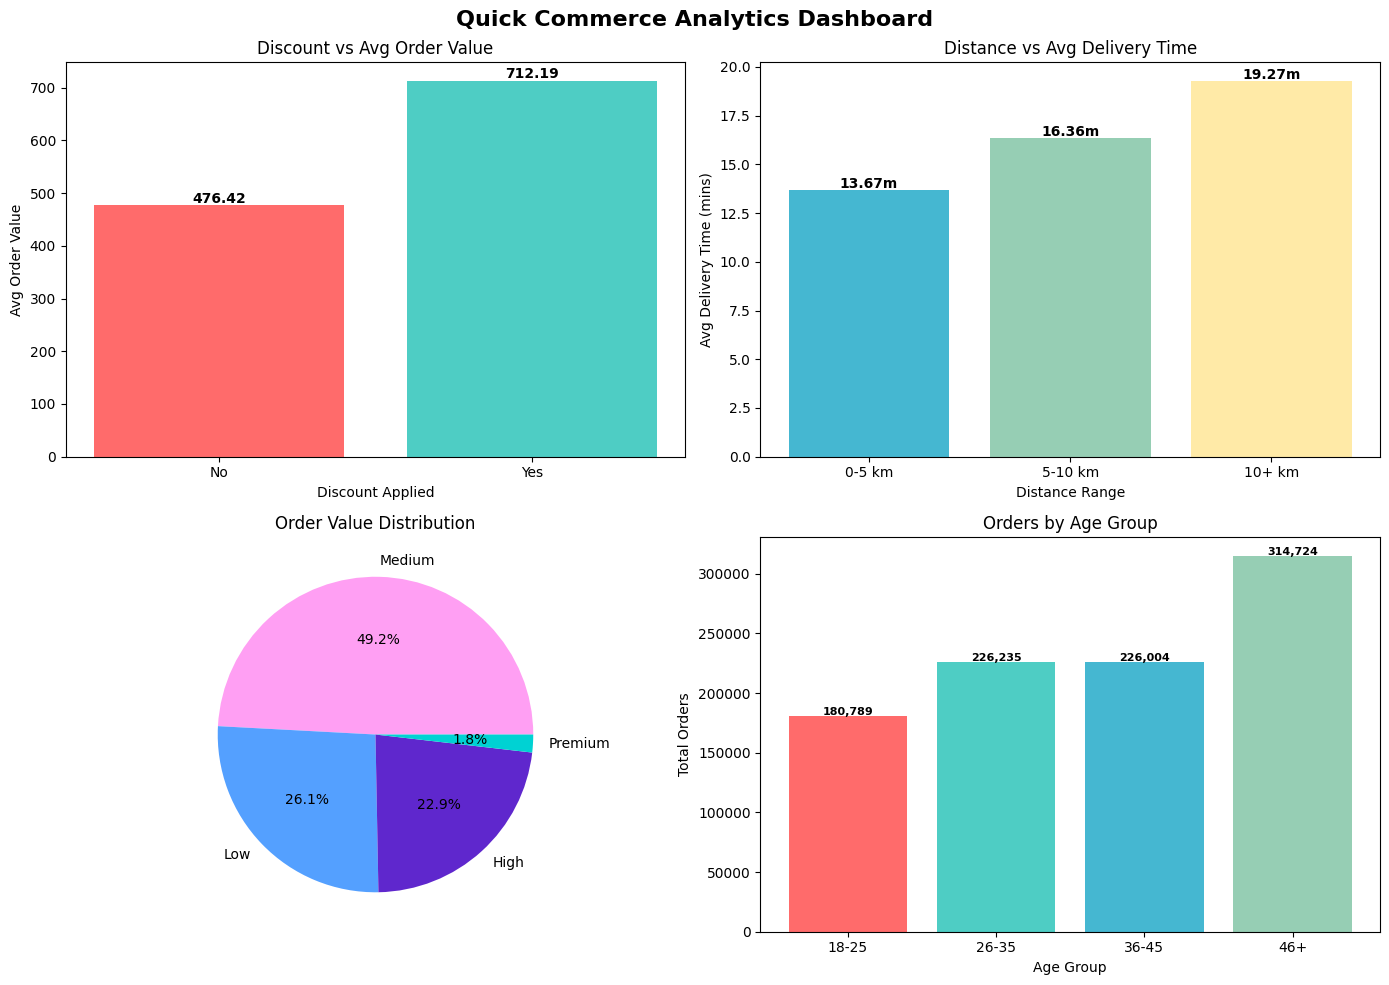

Dashboard saved as quick_commerce_dashboard.png


In [12]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Quick Commerce Analytics Dashboard', fontsize=16, fontweight='bold')

# Chart 1: Discount vs Avg Order Value
axes[0, 0].bar(q2['discount'], q2['avg_order_value'], color=['#FF6B6B', '#4ECDC4'])
axes[0, 0].set_title('Discount vs Avg Order Value')
axes[0, 0].set_xlabel('Discount Applied')
axes[0, 0].set_ylabel('Avg Order Value')
for i, v in enumerate(q2['avg_order_value']):
    axes[0, 0].text(i, v + 5, f'{v}', ha='center', fontweight='bold')

# Chart 2: Distance vs Delivery Time
axes[0, 1].bar(q3['distance_range'], q3['avg_delivery_time'], color=['#45B7D1', '#96CEB4', '#FFEAA7'])
axes[0, 1].set_title('Distance vs Avg Delivery Time')
axes[0, 1].set_xlabel('Distance Range')
axes[0, 1].set_ylabel('Avg Delivery Time (mins)')
for i, v in enumerate(q3['avg_delivery_time']):
    axes[0, 1].text(i, v + 0.1, f'{v}m', ha='center', fontweight='bold')

# Chart 3: Order Value Distribution
q4_viz = pd.read_sql_query("""
    SELECT 
        CASE 
            WHEN order_value <= 300  THEN 'Low'
            WHEN order_value <= 800  THEN 'Medium'
            WHEN order_value <= 1500 THEN 'High'
            ELSE 'Premium'
        END AS order_category,
        COUNT(*) AS total_orders
    FROM fact_orders GROUP BY order_category ORDER BY total_orders DESC
""", conn)
axes[1, 0].pie(q4_viz['total_orders'], labels=q4_viz['order_category'],
               autopct='%1.1f%%', colors=['#FF9FF3', '#54A0FF', '#5F27CD', '#00D2D3'])
axes[1, 0].set_title('Order Value Distribution')

# Chart 4: Orders by Age Group
axes[1, 1].bar(q6['age_group'], q6['total_orders'], color=['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4'])
axes[1, 1].set_title('Orders by Age Group')
axes[1, 1].set_xlabel('Age Group')
axes[1, 1].set_ylabel('Total Orders')
for i, v in enumerate(q6['total_orders']):
    axes[1, 1].text(i, v + 1000, f'{v:,}', ha='center', fontsize=8, fontweight='bold')

plt.tight_layout()
plt.savefig('quick_commerce_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()
print("Dashboard saved as quick_commerce_dashboard.png")

---
## 6. Key Insights Summary

| # | Question | Finding |
|---|----------|---------|
| 1 | Average delivery time | 16.51 mins (range: 5–40 mins) |
| 2 | Discounts vs order value | Discounted orders average 50% higher value (712 vs 476) |
| 3 | Distance vs delivery time | Longer distance = longer delivery (13.67 → 19.27 mins) |
| 4 | Most common order range | Medium orders (300–800) dominate at 49.1% |
| 5 | Delivery partner performance | All partners perform consistently (~16.5 mins) |
| 6 | Top ordering age group | 46+ age group leads with 314,724 orders |

In [13]:
# Close database connection
conn.close()
print("Analysis complete!")

Analysis complete!
